In [1]:
# =========================================================
# Day 3. 지도학습 - 분류 실습
# 실제 업로드 파일 기준: supervised_label_cn7.csv
#
# 목표
# 1) PassOrFail 예측 문제 정의
# 2) train/test split
# 3) baseline 모델
# 4) confusion matrix / classification report 해석
# 5) class imbalance 대응(class_weight, oversampling)
# 6) 하이퍼파라미터 튜닝
# 7) 중요 변수 해석
# =========================================================

In [2]:
# ---------------------------------------------------------
# 1. 라이브러리 불러오기
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
# ---------------------------------------------------------
# 2. 기본 설정
# ---------------------------------------------------------
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 100)
np.random.seed(42)

In [4]:
# ---------------------------------------------------------
# 3. 데이터 불러오기
# ---------------------------------------------------------
file_path = "supervised_label_cn7.csv"
df = pd.read_csv(file_path)

print("=== 원본 데이터 상위 5행 ===")
display(df.head())

=== 원본 데이터 상위 5행 ===


,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
1,1,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
2,2,0,9.58,4.46,16.90,59.580002,7.13,653.409973,68.839996,647.98999,55.599998,30.900000,292.500000,141.699997,136.399994,37.700001,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.6
3,3,0,9.58,4.46,16.92,59.560001,7.13,653.409973,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.6
4,4,0,9.57,4.45,16.91,59.520000,7.14,653.409973,68.830002,647.98999,55.700001,30.799999,292.500000,141.600006,136.399994,37.099998,59.099998,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.5


In [5]:
# ---------------------------------------------------------
# 4. 불필요 컬럼 제거
# ---------------------------------------------------------
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("=== 컬럼 정리 후 상위 5행 ===")
display(df.head())

=== 컬럼 정리 후 상위 5행 ===


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
1,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
2,0,9.58,4.46,16.90,59.580002,7.13,653.409973,68.839996,647.98999,55.599998,30.900000,292.500000,141.699997,136.399994,37.700001,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.6
3,0,9.58,4.46,16.92,59.560001,7.13,653.409973,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.6
4,0,9.57,4.45,16.91,59.520000,7.14,653.409973,68.830002,647.98999,55.700001,30.799999,292.500000,141.600006,136.399994,37.099998,59.099998,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.5


In [6]:
# ---------------------------------------------------------
# 5. 데이터 기본 확인
# ---------------------------------------------------------
print("=== 데이터 크기 ===")
print(df.shape)

print("\n=== 데이터 정보 ===")
df.info()

print("\n=== PassOrFail 분포 ===")
display(df["PassOrFail"].value_counts().sort_index())

print("\n=== PassOrFail 비율(%) ===")
display((df["PassOrFail"].value_counts(normalize=True).sort_index() * 100).round(3))

=== 데이터 크기 ===
(6736, 25)

=== 데이터 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 6736 entries, 0 to 6735
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PassOrFail                6736 non-null   int64  
 1   Injection_Time            6736 non-null   float64
 2   Filling_Time              6736 non-null   float64
 3   Plasticizing_Time         6736 non-null   float64
 4   Cycle_Time                6736 non-null   float64
 5   Clamp_Close_Time          6736 non-null   float64
 6   Cushion_Position          6736 non-null   float64
 7   Plasticizing_Position     6736 non-null   float64
 8   Clamp_Open_Position       6736 non-null   float64
 9   Max_Injection_Speed       6736 non-null   float64
 10  Max_Screw_RPM             6736 non-null   float64
 11  Average_Screw_RPM         6736 non-null   float64
 12  Max_Injection_Pressure    6736 non-null   float64
 13  Max_Switch_Over_Pressure  6736 n

PassOrFail
0    6697
1      39
Name: count, dtype: int64


=== PassOrFail 비율(%) ===


PassOrFail
0    99.421
1     0.579
Name: proportion, dtype: float64

In [7]:
# ---------------------------------------------------------
# 6. 입력(X) / 정답(y) 분리
# ---------------------------------------------------------
target_col = "PassOrFail"
X = df.drop(columns=[target_col])
y = df[target_col]

print("=== X, y 크기 ===")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\n=== 컬럼 목록 ===")
print(X.columns.tolist())

=== X, y 크기 ===
X shape: (6736, 24)
y shape: (6736,)

=== 컬럼 목록 ===
['Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']


In [8]:
# ---------------------------------------------------------
# 7. train / test 분리
#    - 불균형 데이터이므로 stratify 사용
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== train / test 크기 ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\n=== train target 분포 ===")
display(y_train.value_counts().sort_index())

print("\n=== test target 분포 ===")
display(y_test.value_counts().sort_index())

=== train / test 크기 ===
X_train: (5388, 24)
X_test : (1348, 24)
y_train: (5388,)
y_test : (1348,)

=== train target 분포 ===


PassOrFail
0    5357
1      31
Name: count, dtype: int64


=== test target 분포 ===


PassOrFail
0    1340
1       8
Name: count, dtype: int64

In [9]:
# ---------------------------------------------------------
# 8. 공통 평가 함수
# ---------------------------------------------------------
def evaluate_binary_model(model, X_train, y_train, X_test, y_test, model_name="model"):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"=== {model_name} ===")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))

    if y_score is not None:
        roc_auc = roc_auc_score(y_test, y_score)
        print("ROC-AUC  :", round(roc_auc, 4))
    else:
        roc_auc = np.nan
        print("ROC-AUC  : 계산 불가")

    print("\n[Classification Report]")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "model_name": model_name,
        "model": model,
        "y_pred": y_pred,
        "y_score": y_score,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc
    }


=== Baseline - Logistic Regression ===
Accuracy : 0.9978
Precision: 1.0
Recall   : 0.625
F1-score : 0.7692
ROC-AUC  : 0.9292

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       1.00      0.62      0.77         8

    accuracy                           1.00      1348
   macro avg       1.00      0.81      0.88      1348
weighted avg       1.00      1.00      1.00      1348



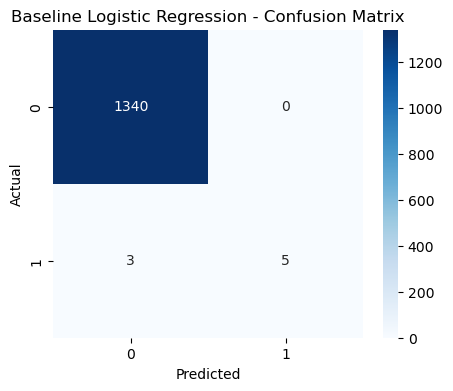

In [10]:
# ---------------------------------------------------------
# 9. 기준 모델 1: Logistic Regression
# ---------------------------------------------------------
log_model = LogisticRegression(max_iter=3000, random_state=42)
result_log = evaluate_binary_model(
    log_model, X_train, y_train, X_test, y_test,
    model_name="Baseline - Logistic Regression"
)

cm_log = confusion_matrix(y_test, result_log["y_pred"])

plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Baseline - Decision Tree ===
Accuracy : 0.9955
Precision: 0.625
Recall   : 0.625
F1-score : 0.625
ROC-AUC  : 0.8116

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       0.62      0.62      0.62         8

    accuracy                           1.00      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       1.00      1.00      1.00      1348



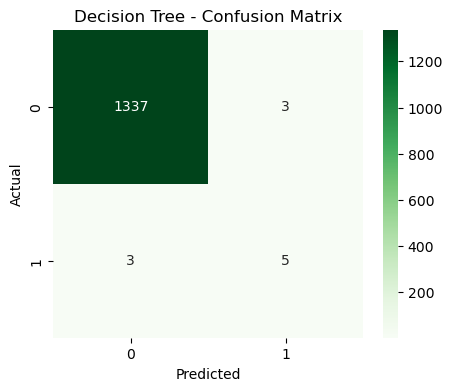

In [11]:
# ---------------------------------------------------------
# 10. 기준 모델 2: Decision Tree
# ---------------------------------------------------------
tree_model = DecisionTreeClassifier(random_state=42)
result_tree = evaluate_binary_model(
    tree_model, X_train, y_train, X_test, y_test,
    model_name="Baseline - Decision Tree"
)

cm_tree = confusion_matrix(y_test, result_tree["y_pred"])

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Baseline - Random Forest ===
Accuracy : 0.9955
Precision: 0.625
Recall   : 0.625
F1-score : 0.625
ROC-AUC  : 0.931

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       0.62      0.62      0.62         8

    accuracy                           1.00      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       1.00      1.00      1.00      1348



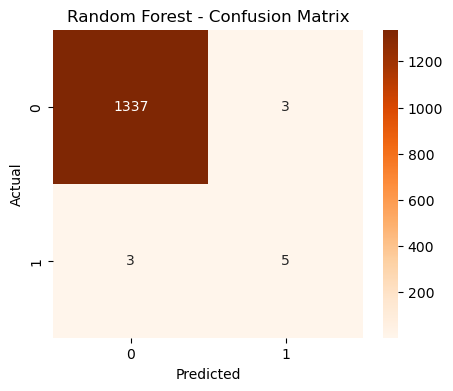

In [12]:
# ---------------------------------------------------------
# 11. 기준 모델 3: Random Forest
# ---------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
result_rf = evaluate_binary_model(
    rf_model, X_train, y_train, X_test, y_test,
    model_name="Baseline - Random Forest"
)

cm_rf = confusion_matrix(y_test, result_rf["y_pred"])

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
# ---------------------------------------------------------
# 12. baseline 모델 비교표
# ---------------------------------------------------------
baseline_compare = pd.DataFrame([
    {
        "model": result_log["model_name"],
        "accuracy": result_log["accuracy"],
        "precision": result_log["precision"],
        "recall": result_log["recall"],
        "f1": result_log["f1"],
        "roc_auc": result_log["roc_auc"]
    },
    {
        "model": result_tree["model_name"],
        "accuracy": result_tree["accuracy"],
        "precision": result_tree["precision"],
        "recall": result_tree["recall"],
        "f1": result_tree["f1"],
        "roc_auc": result_tree["roc_auc"]
    },
    {
        "model": result_rf["model_name"],
        "accuracy": result_rf["accuracy"],
        "precision": result_rf["precision"],
        "recall": result_rf["recall"],
        "f1": result_rf["f1"],
        "roc_auc": result_rf["roc_auc"]
    }
]).sort_values("f1", ascending=False)

print("\n=== Baseline 모델 비교표 ===")
display(baseline_compare)


=== Baseline 모델 비교표 ===


,model,accuracy,precision,recall,f1,roc_auc
0,Baseline - Logistic Regression,0.997774,1.000,0.625,0.769231,0.929244
1,Baseline - Decision Tree,0.995549,0.625,0.625,0.625000,0.811614
2,Baseline - Random Forest,0.995549,0.625,0.625,0.625000,0.931017


In [14]:
# ---------------------------------------------------------
# 13. class_weight='balanced' 적용
# ---------------------------------------------------------
log_balanced = LogisticRegression(
    max_iter=3000,
    random_state=42,
    class_weight="balanced"
)
result_log_balanced = evaluate_binary_model(
    log_balanced, X_train, y_train, X_test, y_test,
    model_name="Logistic Regression (class_weight='balanced')"
)

rf_balanced = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)
result_rf_balanced = evaluate_binary_model(
    rf_balanced, X_train, y_train, X_test, y_test,
    model_name="Random Forest (class_weight='balanced')"
)

=== Logistic Regression (class_weight='balanced') ===
Accuracy : 0.9592
Precision: 0.0877
Recall   : 0.625
F1-score : 0.1538
ROC-AUC  : 0.9576

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1340
           1       0.09      0.62      0.15         8

    accuracy                           0.96      1348
   macro avg       0.54      0.79      0.57      1348
weighted avg       0.99      0.96      0.97      1348

=== Random Forest (class_weight='balanced') ===
Accuracy : 0.9955
Precision: 0.625
Recall   : 0.625
F1-score : 0.625
ROC-AUC  : 0.9964

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       0.62      0.62      0.62         8

    accuracy                           1.00      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       1.00      1.00      1.00      1348



In [15]:
# ---------------------------------------------------------
# 14. class_weight 적용 모델 비교
# ---------------------------------------------------------
balanced_compare = pd.DataFrame([
    {
        "model": result_log["model_name"],
        "accuracy": result_log["accuracy"],
        "precision": result_log["precision"],
        "recall": result_log["recall"],
        "f1": result_log["f1"]
    },
    {
        "model": result_log_balanced["model_name"],
        "accuracy": result_log_balanced["accuracy"],
        "precision": result_log_balanced["precision"],
        "recall": result_log_balanced["recall"],
        "f1": result_log_balanced["f1"]
    },
    {
        "model": result_rf["model_name"],
        "accuracy": result_rf["accuracy"],
        "precision": result_rf["precision"],
        "recall": result_rf["recall"],
        "f1": result_rf["f1"]
    },
    {
        "model": result_rf_balanced["model_name"],
        "accuracy": result_rf_balanced["accuracy"],
        "precision": result_rf_balanced["precision"],
        "recall": result_rf_balanced["recall"],
        "f1": result_rf_balanced["f1"]
    }
])

print("=== class_weight 적용 전후 비교 ===")
display(balanced_compare)

=== class_weight 적용 전후 비교 ===


,model,accuracy,precision,recall,f1
0,Baseline - Logistic Regression,0.997774,1.000000,0.625,0.769231
1,Logistic Regression (class_weight='balanced'),0.959199,0.087719,0.625,0.153846
2,Baseline - Random Forest,0.995549,0.625000,0.625,0.625000
3,Random Forest (class_weight='balanced'),0.995549,0.625000,0.625,0.625000


In [16]:
# ---------------------------------------------------------
# 15. 간단한 oversampling
#    - train 데이터에서만 수행
# ---------------------------------------------------------
train_df = X_train.copy()
train_df[target_col] = y_train.values

majority_df = train_df[train_df[target_col] == 0]
minority_df = train_df[train_df[target_col] == 1]

print("=== Oversampling 전 클래스 개수 ===")
display(train_df[target_col].value_counts().sort_index())

minority_oversampled = minority_df.sample(
    n=len(majority_df),
    replace=True,
    random_state=42
)

train_balanced = pd.concat([majority_df, minority_oversampled], axis=0)

print("=== Oversampling 후 클래스 개수 ===")
display(train_balanced[target_col].value_counts().sort_index())

X_train_over = train_balanced.drop(columns=[target_col])
y_train_over = train_balanced[target_col]

=== Oversampling 전 클래스 개수 ===


PassOrFail
0    5357
1      31
Name: count, dtype: int64

=== Oversampling 후 클래스 개수 ===


PassOrFail
0    5357
1    5357
Name: count, dtype: int64

In [17]:
# ---------------------------------------------------------
# 16. oversampling 후 Logistic Regression
# ---------------------------------------------------------
log_over = LogisticRegression(max_iter=3000, random_state=42)
result_log_over = evaluate_binary_model(
    log_over, X_train_over, y_train_over, X_test, y_test,
    model_name="Logistic Regression (oversampling)"
)

=== Logistic Regression (oversampling) ===
Accuracy : 0.9607
Precision: 0.0909
Recall   : 0.625
F1-score : 0.1587
ROC-AUC  : 0.9585

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1340
           1       0.09      0.62      0.16         8

    accuracy                           0.96      1348
   macro avg       0.54      0.79      0.57      1348
weighted avg       0.99      0.96      0.97      1348



In [18]:
# ---------------------------------------------------------
# 17. oversampling 후 Random Forest
# ---------------------------------------------------------
rf_over = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
result_rf_over = evaluate_binary_model(
    rf_over, X_train_over, y_train_over, X_test, y_test,
    model_name="Random Forest (oversampling)"
)

=== Random Forest (oversampling) ===
Accuracy : 0.9955
Precision: 0.625
Recall   : 0.625
F1-score : 0.625
ROC-AUC  : 0.995

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       0.62      0.62      0.62         8

    accuracy                           1.00      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       1.00      1.00      1.00      1348



In [19]:
# ---------------------------------------------------------
# 18. 불균형 대응 방법 비교표
# ---------------------------------------------------------
imbalance_compare = pd.DataFrame([
    {
        "model": result_log["model_name"],
        "accuracy": result_log["accuracy"],
        "precision": result_log["precision"],
        "recall": result_log["recall"],
        "f1": result_log["f1"]
    },
    {
        "model": result_log_balanced["model_name"],
        "accuracy": result_log_balanced["accuracy"],
        "precision": result_log_balanced["precision"],
        "recall": result_log_balanced["recall"],
        "f1": result_log_balanced["f1"]
    },
    {
        "model": result_log_over["model_name"],
        "accuracy": result_log_over["accuracy"],
        "precision": result_log_over["precision"],
        "recall": result_log_over["recall"],
        "f1": result_log_over["f1"]
    },
    {
        "model": result_rf["model_name"],
        "accuracy": result_rf["accuracy"],
        "precision": result_rf["precision"],
        "recall": result_rf["recall"],
        "f1": result_rf["f1"]
    },
    {
        "model": result_rf_balanced["model_name"],
        "accuracy": result_rf_balanced["accuracy"],
        "precision": result_rf_balanced["precision"],
        "recall": result_rf_balanced["recall"],
        "f1": result_rf_balanced["f1"]
    },
    {
        "model": result_rf_over["model_name"],
        "accuracy": result_rf_over["accuracy"],
        "precision": result_rf_over["precision"],
        "recall": result_rf_over["recall"],
        "f1": result_rf_over["f1"]
    }
]).sort_values("f1", ascending=False)

print("=== 불균형 대응 방법 비교 ===")
display(imbalance_compare)

=== 불균형 대응 방법 비교 ===


,model,accuracy,precision,recall,f1
0,Baseline - Logistic Regression,0.997774,1.000000,0.625,0.769231
3,Baseline - Random Forest,0.995549,0.625000,0.625,0.625000
4,Random Forest (class_weight='balanced'),0.995549,0.625000,0.625,0.625000
5,Random Forest (oversampling),0.995549,0.625000,0.625,0.625000
2,Logistic Regression (oversampling),0.960682,0.090909,0.625,0.158730
1,Logistic Regression (class_weight='balanced'),0.959199,0.087719,0.625,0.153846


=== Random Forest 중요 변수 ===


,feature,importance
1,Filling_Time,0.136309
8,Max_Injection_Speed,0.124755
12,Max_Switch_Over_Pressure,0.096903
5,Cushion_Position,0.083781
0,Injection_Time,0.059868
11,Max_Injection_Pressure,0.053355
2,Plasticizing_Time,0.048732
13,Max_Back_Pressure,0.036251
14,Average_Back_Pressure,0.035372
21,Hopper_Temperature,0.032364


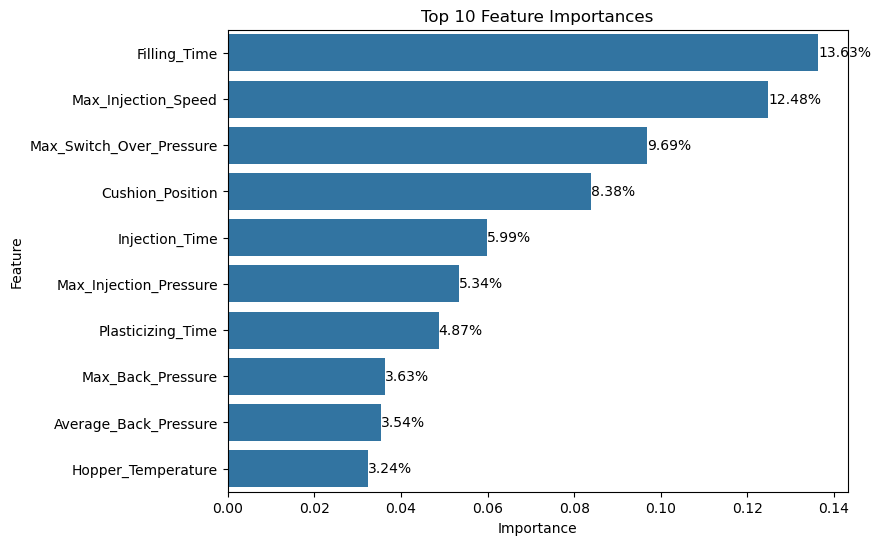

In [20]:
# ---------------------------------------------------------
# 19. 중요 변수 확인 - Random Forest 기준
# ---------------------------------------------------------
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": result_rf["model"].feature_importances_
}).sort_values("importance", ascending=False)

print("=== Random Forest 중요 변수 ===")
display(importance_df)

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=importance_df.head(10), x="importance", y="feature")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


=== GridSearchCV 결과 ===
Best Params: {'class_weight': None, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1: 0.7992

=== Tuned Random Forest 결과 ===
Accuracy : 0.9978
Precision: 1.0
Recall   : 0.625
F1-score : 0.7692
ROC-AUC  : 0.9928

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       1.00      0.62      0.77         8

    accuracy                           1.00      1348
   macro avg       1.00      0.81      0.88      1348
weighted avg       1.00      1.00      1.00      1348



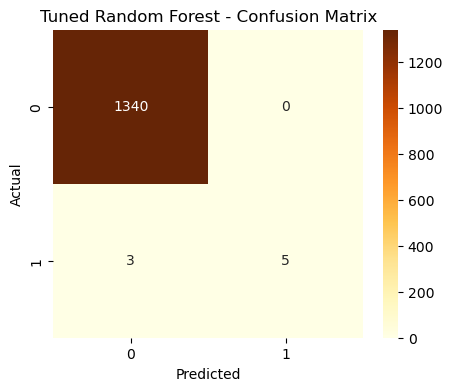

In [21]:
# ---------------------------------------------------------
# 20. 하이퍼파라미터 튜닝 - Random Forest
# ---------------------------------------------------------
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5],
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\n=== GridSearchCV 결과 ===")
print("Best Params:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 4))

best_rf = grid.best_estimator_
best_rf_pred = best_rf.predict(X_test)
best_rf_score = best_rf.predict_proba(X_test)[:, 1]

print("\n=== Tuned Random Forest 결과 ===")
print("Accuracy :", round(accuracy_score(y_test, best_rf_pred), 4))
print("Precision:", round(precision_score(y_test, best_rf_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, best_rf_pred, zero_division=0), 4))
print("F1-score :", round(f1_score(y_test, best_rf_pred, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, best_rf_score), 4))
print("\n[Classification Report]")
print(classification_report(y_test, best_rf_pred, zero_division=0))

cm_best_rf = confusion_matrix(y_test, best_rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_best_rf, annot=True, fmt="d", cmap="YlOrBr")
plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
# ---------------------------------------------------------
# 21. 튜닝 전후 비교
# ---------------------------------------------------------
tuned_compare = pd.DataFrame([
    {
        "model": "Baseline - Random Forest",
        "accuracy": result_rf["accuracy"],
        "precision": result_rf["precision"],
        "recall": result_rf["recall"],
        "f1": result_rf["f1"],
        "roc_auc": result_rf["roc_auc"]
    },
    {
        "model": "Tuned Random Forest",
        "accuracy": accuracy_score(y_test, best_rf_pred),
        "precision": precision_score(y_test, best_rf_pred, zero_division=0),
        "recall": recall_score(y_test, best_rf_pred, zero_division=0),
        "f1": f1_score(y_test, best_rf_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, best_rf_score)
    }
])

print("\n=== 튜닝 전후 비교 ===")
display(tuned_compare)


=== 튜닝 전후 비교 ===


,model,accuracy,precision,recall,f1,roc_auc
0,Baseline - Random Forest,0.995549,0.625,0.625,0.625000,0.931017
1,Tuned Random Forest,0.997774,1.000,0.625,0.769231,0.992771


In [23]:
# ---------------------------------------------------------
# 22. 예측 확률 상위 실패 위험 샘플 보기
# ---------------------------------------------------------
result_test = X_test.copy()
result_test["actual"] = y_test.values
result_test["pred_best_rf"] = best_rf_pred
result_test["pred_prob_fail"] = best_rf_score

print("=== 불량 예측 확률 상위 10개 샘플 ===")
display(
    result_test.sort_values("pred_prob_fail", ascending=False).head(10)
)

=== 불량 예측 확률 상위 10개 샘플 ===


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,actual,pred_best_rf,pred_prob_fail
2023,11.49,6.37,16.750000,62.360001,7.18,653.429993,68.589996,647.98999,45.099998,30.500000,292.500000,145.699997,144.199997,43.700001,62.900002,275.200012,275.500000,274.899994,272.100006,255.199997,230.100006,64.300003,20.500000,21.799999,1,1,0.980006
643,11.49,6.37,16.750000,62.360001,7.18,653.429993,68.589996,647.98999,45.099998,30.500000,292.500000,145.699997,144.199997,43.700001,62.900002,275.200012,275.500000,274.899994,272.100006,255.199997,230.100006,64.300003,20.500000,21.799999,1,1,0.980006
5390,10.83,5.72,16.820000,62.360001,7.18,653.390015,68.580002,647.98999,45.400002,31.100000,292.399994,144.899994,142.699997,71.900002,87.099998,276.000000,274.799988,275.700012,268.899994,255.199997,229.800003,63.799999,20.600000,21.799999,1,1,0.970201
642,10.83,5.72,16.820000,62.360001,7.18,653.390015,68.580002,647.98999,45.400002,31.100000,292.399994,144.899994,142.699997,71.900002,87.099998,276.000000,274.799988,275.700012,268.899994,255.199997,229.800003,63.799999,20.600000,21.799999,1,1,0.970201
4010,9.98,4.87,16.530001,60.459999,7.12,653.409973,68.610001,647.98999,49.400002,30.700001,292.500000,142.899994,139.000000,50.599998,67.400002,276.000000,275.299988,275.100006,271.600006,255.199997,229.600006,65.000000,20.700001,22.000000,1,1,0.970006
55,9.58,4.46,16.950001,59.520000,7.14,653.409973,68.860001,647.98999,55.500000,30.900000,292.500000,141.800003,136.500000,37.099998,59.099998,277.100006,275.299988,275.100006,269.500000,255.300003,229.800003,67.800003,25.000000,27.700001,0,0,0.215282
5138,9.60,4.48,16.580000,59.520000,7.11,653.429993,68.360001,647.98999,55.000000,30.600000,29.200001,142.100006,136.800003,38.299999,59.900002,277.299988,275.200012,274.899994,271.500000,255.100006,230.100006,65.300003,22.200001,24.000000,0,0,0.111900
604,9.36,4.24,21.100000,59.360001,7.12,653.450012,68.120003,647.98999,60.500000,31.200001,293.899994,140.699997,133.100006,37.200001,57.700001,276.200012,275.000000,275.299988,271.700012,254.899994,230.500000,69.500000,23.500000,24.500000,0,0,0.077629
3426,9.58,4.46,16.900000,59.400002,7.13,653.409973,68.839996,647.98999,55.599998,30.600000,292.500000,141.800003,136.699997,36.400002,58.799999,276.100006,275.399994,274.500000,271.399994,255.300003,229.699997,66.800003,25.000000,27.700001,0,0,0.059403
137,9.59,4.47,16.910000,59.520000,7.12,653.409973,68.849998,647.98999,55.299999,30.799999,292.500000,141.800003,136.800003,37.599998,59.400002,275.700012,275.299988,274.500000,271.700012,254.699997,229.899994,67.699997,25.100000,27.600000,0,0,0.046694


In [24]:
# ---------------------------------------------------------
# 23. 오분류 샘플 확인
# ---------------------------------------------------------
misclassified_df = result_test[result_test["actual"] != result_test["pred_best_rf"]].copy()

print("\n=== 오분류 샘플 개수 ===")
print(len(misclassified_df))

print("\n=== 오분류 샘플 일부 ===")
display(misclassified_df.head(10))


=== 오분류 샘플 개수 ===
3

=== 오분류 샘플 일부 ===


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,actual,pred_best_rf,pred_prob_fail
3419,9.56,4.44,16.920000,59.52,7.13,653.409973,68.839996,647.98999,55.799999,30.700001,292.5,141.600006,136.100006,37.000000,59.000000,275.200012,274.700012,274.299988,270.500000,254.699997,230.100006,67.500000,25.000000,27.600000,1,0,0.010705
3422,9.58,4.46,16.959999,59.52,7.13,653.409973,68.839996,647.98999,55.799999,30.900000,292.5,141.800003,136.800003,37.200001,59.099998,276.000000,274.700012,275.700012,269.600006,254.500000,230.300003,67.099998,25.100000,27.700001,1,0,0.034442
3413,9.59,4.48,16.950001,59.52,7.13,653.419983,68.839996,647.98999,55.299999,30.700001,292.5,141.800003,136.899994,37.299999,59.200001,276.100006,276.299988,275.200012,270.000000,254.100006,230.399994,68.500000,25.200001,27.700001,1,0,0.028588


In [25]:
# ---------------------------------------------------------
# 24. 발표/워크숍용 질문
# ---------------------------------------------------------
print("\n=== 워크숍 질문 ===")
print("1. accuracy가 높아도 recall이 낮을 수 있는 이유는 무엇인가?")
print("2. class_weight와 oversampling 중 어떤 방식이 더 효과적이었는가?")
print("3. confusion matrix에서 FN(불량을 정상으로 예측)은 몇 개인가?")
print("4. 어떤 변수들이 불량 예측에 중요했는가?")
print("5. 현업에서는 precision과 recall 중 무엇을 더 중시해야 할까?")


=== 워크숍 질문 ===
1. accuracy가 높아도 recall이 낮을 수 있는 이유는 무엇인가?
2. class_weight와 oversampling 중 어떤 방식이 더 효과적이었는가?
3. confusion matrix에서 FN(불량을 정상으로 예측)은 몇 개인가?
4. 어떤 변수들이 불량 예측에 중요했는가?
5. 현업에서는 precision과 recall 중 무엇을 더 중시해야 할까?


In [26]:
# ---------------------------------------------------------
# 25. 4주차 연결 질문
# ---------------------------------------------------------
print("\n=== 다음 시간 생각해볼 질문 ===")
print("- 이번에는 불량/정상을 맞혔는데, 숫자를 예측하는 회귀는 무엇이 다를까?")
print("- 회귀에서는 어떤 지표(MAE, RMSE, R²)를 봐야 할까?")
print("- 분류와 달리 confusion matrix가 없는 회귀는 어떻게 해석할까?")


=== 다음 시간 생각해볼 질문 ===
- 이번에는 불량/정상을 맞혔는데, 숫자를 예측하는 회귀는 무엇이 다를까?
- 회귀에서는 어떤 지표(MAE, RMSE, R²)를 봐야 할까?
- 분류와 달리 confusion matrix가 없는 회귀는 어떻게 해석할까?


In [27]:
# ---------------------------------------------------------
# 26. 최종 정리
# ---------------------------------------------------------
print("\n=== 오늘 실습 정리 ===")
print("1. PassOrFail 분류 문제를 정의했다.")
print("2. baseline 모델(Logistic, Tree, Random Forest)을 비교했다.")
print("3. confusion matrix와 classification report를 해석했다.")
print("4. class_weight와 oversampling으로 불균형 데이터를 다뤘다.")
print("5. Random Forest 하이퍼파라미터 튜닝을 수행했다.")
print("6. 중요 변수와 오분류 샘플까지 확인했다.")


=== 오늘 실습 정리 ===
1. PassOrFail 분류 문제를 정의했다.
2. baseline 모델(Logistic, Tree, Random Forest)을 비교했다.
3. confusion matrix와 classification report를 해석했다.
4. class_weight와 oversampling으로 불균형 데이터를 다뤘다.
5. Random Forest 하이퍼파라미터 튜닝을 수행했다.
6. 중요 변수와 오분류 샘플까지 확인했다.


In [28]:
# end